In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
# from statsmodels.stats.weightstats import ztest as ztest
from scipy.stats import ttest_ind as ttest
import statsmodels.formula.api as smf

savefig_settings = {'bbox_inches': 'tight', 'facecolor': 'w', 'dpi': 300}
save_fig = True

## Read timeseries stats

In [2]:
#day = datetime.today().strftime('%Y-%m-%d')
day = '2024-11-19'
sample =  'all' # 'randomsample500' 

metadata = pd.read_csv("./data/combined_tech_characteristics.csv", index_col=0)
ts_stats = pd.read_csv(f"./results/timeseries_stats_{sample}_2024-10-22.csv", index_col=0)
params = pd.read_csv(f"./results/fitting_parameters_{sample}_{day}.csv", index_col=0)

day = '2024-10-22'
hindcast = pd.read_csv(f"./results/hindcasting_results_{sample}_{day}.csv", index_col=0)

In [3]:
params = params.loc[params['fit_success']]
# metadata['Technology Name'] = metadata.index

In [4]:
full_table = pd.merge(hindcast, ts_stats, how = 'left', left_on = 'technology', right_on = 'tech_name')
full_table = pd.merge(full_table, metadata, how = 'left', left_on = 'Technology Name', right_on='Technology Name')
full_table['Hindcast_MAPE_log'] = np.log10(full_table['Hindcast_MAPE'])
full_table = full_table[(full_table['Category Type'] == 'Energy Supply') | (full_table['Category Type'] == 'Infrastructure') | (full_table['Category Type'] == 'Storage Technology') | ((full_table['Category Type'] == 'Appliances') & (full_table['Patent Category Name'] == 'Mechanical Engineering; Lighting; Heating; Weapons; Blasting'))]
#full_table

C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
full_table.columns

Index(['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'technology', 'Length_test', 'Hindcast_MAPE', 'd', 'd_std',
       'error_type', 'error_msg', 'n', 'dt_mean', 'dt_std', 'y_median',
       'y_mean', 'y_std', 'y_min', 'y_max', 'y_min_rel_pos', 'y_max_rel_pos',
       'y_pct_mean_drop_after_max', 'y_trend_slope', 'y_trend_pval', 'dy_mean',
       'dy_std', 'dy_cv', 'dy_trend_slope', 'dy_trend_pval', 'ddy_mean',
       'ddy_std', 'ddy_trend_slope', 'ddy_trend_pval', 'ar1', 'ar2',
       'roughness', 'lastm', 'lastm_convexity_sign', 'lastm_convexity_mean',
       'lastm_convexity_pvalue', 'lastm_slope_sign', 'lastm_slope_mean',
       'lastm_lin_pvalue', 'ratio_last1m_v_first', 'tech_name',
       'Technology Name', 'Material Use Numerical', 'Final Material Use',
       'Year of Invention', 'Year of First Embodiment of Tech',
       'FirstCommercialYr', 'Need for Customizatio

In [6]:
# full_table['adj_r_squared'].describe()
# full_table.loc[full_table['adj_r_squared'] < 0, 'adj_r_squared'] = 0

def sigmoid(x):
    try:
        return (1+np.exp(-1))/(1+np.exp(-x))
    except Exception as error:
        return np.nan
    
full_table['sig_ar2'] = sigmoid(full_table['adj_r_squared'])
full_table['ar20'] = full_table['adj_r_squared']
full_table.loc[full_table['ar20'] < 0, 'ar20'] = 0

C:\Users\zacht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [8]:
full_table['Hindcast_MAPE'].corr(full_table['ar20'])

np.float64(0.00255296249949501)

In [8]:
pd.options.display.float_format = '{:.2f}'.format

In [39]:
full_table['MAPE_rank'] = full_table.groupby('technology')['Hindcast_MAPE_log'].rank(method='min')
best_mape = full_table.loc[full_table['MAPE_rank'] == 1,]
bav = best_mape['functional_form'].value_counts()
bav

functional_form
exponential             256
bass                    190
bertalanffy             166
softplus                157
logistic                118
linear                  118
gompertz                 73
richards                 51
logistic-linear-cont     15
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x1efd95f88d0>,
 [Text(0.8391869066124568, 0.7111718046788805, 'exponential'),
  Text(-0.3844106360947973, 1.030644683126631, 'bass'),
  Text(-1.0694657513285277, 0.25737716824790036, 'bertalanffy'),
  Text(-0.8751346552759665, -0.6664377953980517, 'softplus'),
  Text(-0.18042656737334245, -1.085101955479702, 'logistic'),
  Text(0.51119615703387, -0.9740012777372539, 'linear'),
  Text(0.9302470154057283, -0.587060891499966, 'gompertz'),
  Text(1.072898833069058, -0.24266869183941597, 'richards'),
  Text(1.0990669079146902, -0.04529825522955905, 'logistic-linear-cont')])

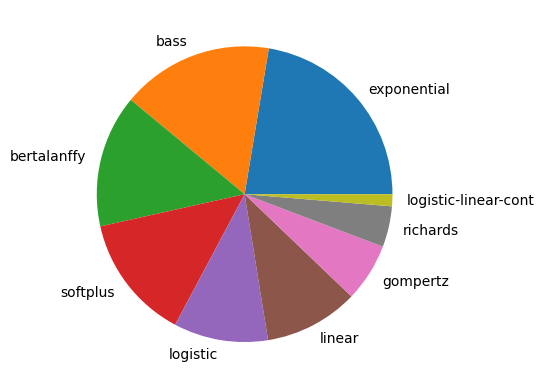

In [40]:
fig, ax = plt.subplots()
ax.pie(bav, labels = bav.index)

In [29]:
#full_table[high_adj_r2] = full_table[full_table['adj_r_squared'] > 0.9]
full_table.loc[(full_table['adj_r_squared'] >= 0.65) & (full_table['n'] > 15), 'usefulness'] = 'good_long'
full_table.loc[(full_table['adj_r_squared'] < 0.65) & (full_table['n'] > 15), 'usefulness'] = 'bad_long'
full_table.loc[(full_table['adj_r_squared'] >= 0.65) & (full_table['n'] <= 15), 'usefulness'] = 'good_short'
full_table.loc[(full_table['adj_r_squared'] < 0.65) & (full_table['n'] <= 15), 'usefulness'] = 'bad_short'
full_table['usefulness'].value_counts()

usefulness
good_long     6476
bad_long      2707
good_short     610
bad_short      400
Name: count, dtype: int64

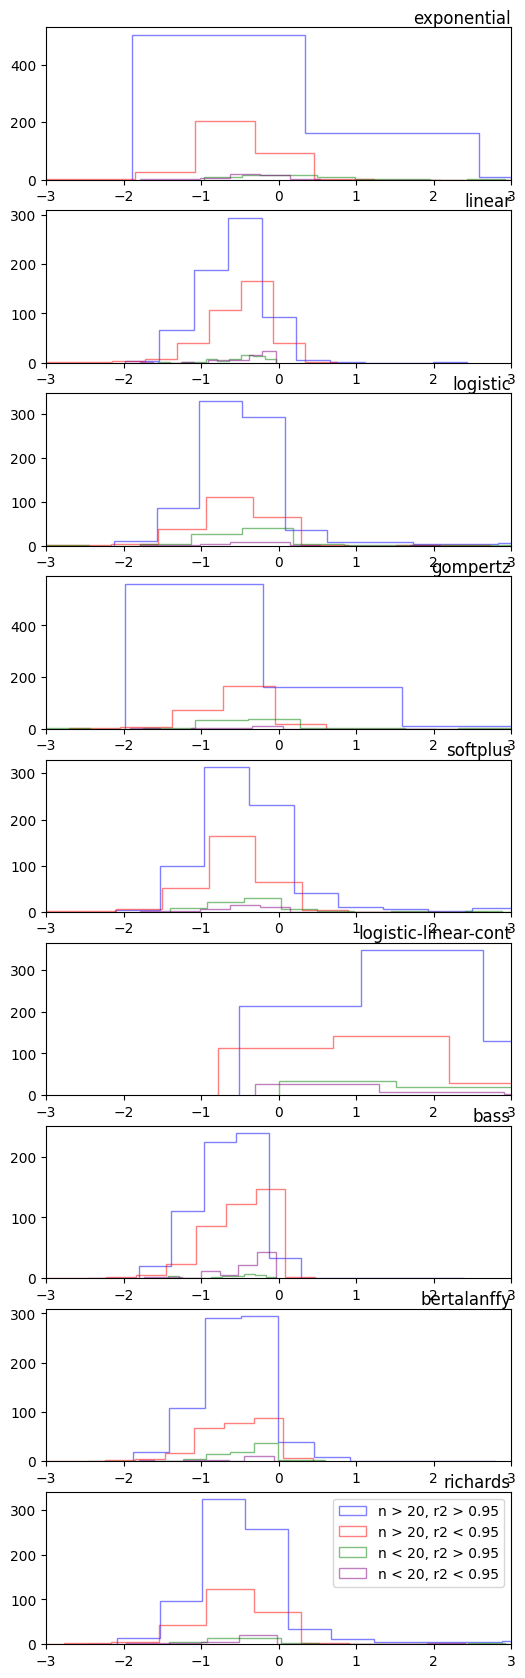

In [30]:
plot_table = full_table[(full_table["Hindcast_MAPE_log"] > -np.inf) & (full_table["Hindcast_MAPE_log"] < np.inf)]
# plot_table.groupby(['ar_high_low', 'functional_form'])['Hindcast_MAPE'].mean().unstack()

fig, ax = plt.subplots(9,1, figsize = (6,21))

count=0
for ff in plot_table['functional_form'].unique():
    ff_dy0 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['usefulness'] == 'good_long')]['Hindcast_MAPE_log']
    ff_dy1 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['usefulness'] =='bad_long')]['Hindcast_MAPE_log']
    ff_dy2 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['usefulness'] == 'good_short')]['Hindcast_MAPE_log']
    ff_dy3 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['usefulness'] =='bad_short')]['Hindcast_MAPE_log']
    ax[count].hist(ff_dy0, histtype = 'step', alpha = 0.5, color = 'blue', label = 'n > 20, r2 > 0.95')
    ax[count].hist(ff_dy1, histtype = 'step', alpha = 0.5, color = 'red', label = 'n > 20, r2 < 0.95')
    ax[count].hist(ff_dy2, histtype = 'step', alpha = 0.5, color = 'green', label = 'n < 20, r2 > 0.95')
    ax[count].hist(ff_dy3, histtype = 'step', alpha = 0.5, color = 'purple', label = 'n < 20, r2 < 0.95')
    ax[count].set_xlim(left = -3, right = 3)
    ax[count].set_title(ff, loc='right', pad = 0)
    count += 1
    

plt.legend()
plt.show()

In [26]:
data1 = full_table['Hindcast_MAPE'][(full_table['usefulness'] == 'good_long') & (full_table['functional_form'] == 'bass')]
data2 = full_table['Hindcast_MAPE'][(full_table['usefulness'] == 'bad_short') & (full_table['functional_form'] == 'bass')]
tstat, pvalue = ttest(data1, data2)
print(tstat, pvalue)

-6.277899510752329 1.2241217151120985e-09


In [10]:
full_table['dy_trend_slope_sign'] = np.sign(full_table['dy_trend_slope']) * (full_table['dy_trend_pval'] < 0.05)
full_table['dy_trend_slope_sign'].value_counts()

C:\Users\zacht\AppData\Local\Temp\ipykernel_22216\141732799.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_table['dy_trend_slope_sign'] = np.sign(full_table['dy_trend_slope']) * (full_table['dy_trend_pval'] < 0.05)


dy_trend_slope_sign
-0.00    2157
1.00     1116
-1.00     893
Name: count, dtype: int64

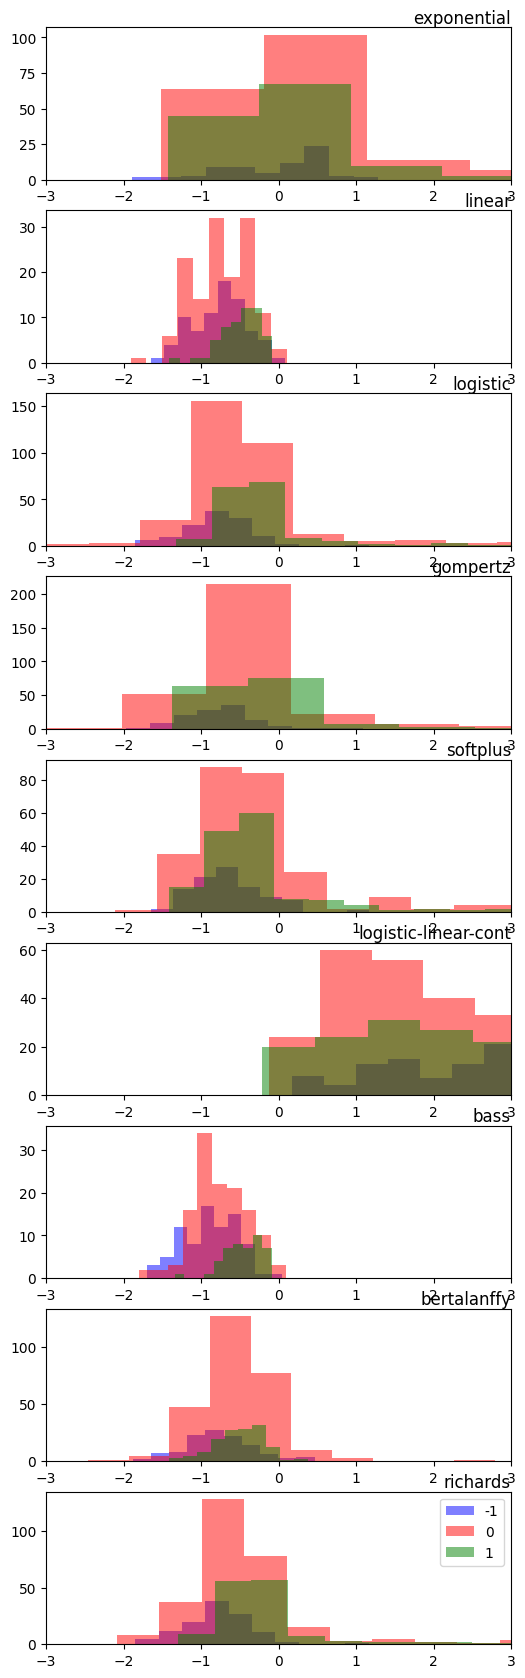

In [11]:
plot_table = full_table[(full_table["Hindcast_MAPE_log"] > -np.inf) & (full_table["Hindcast_MAPE_log"] < np.inf)]
# plot_table.groupby(['dy_trend_slope_sign', 'functional_form'])['Hindcast_MAPE'].mean().unstack()

fig, ax = plt.subplots(9,1, figsize = (6,21))
count=0
for ff in plot_table['functional_form'].unique():
    ff_dy0 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['dy_trend_slope_sign'] == -1)]['Hindcast_MAPE_log']
    ff_dy1 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['dy_trend_slope_sign'] == 0)]['Hindcast_MAPE_log']
    ff_dy2 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['dy_trend_slope_sign'] == 1)]['Hindcast_MAPE_log']
    ax[count].hist(ff_dy0, alpha = 0.5, color = 'blue', label = '-1')
    ax[count].hist(ff_dy1, alpha = 0.5, color = 'red', label = '0')
    ax[count].hist(ff_dy2, alpha = 0.5, color = 'green', label = '1')
    ax[count].set_xlim(left = -3, right = 3)
    ax[count].set_title(ff, loc='right', pad = 0)
    count += 1
    

plt.legend()
plt.show()

In [12]:
full_table['ar_high_low'] = full_table['ar1'].apply(lambda x: 'high' if x > 0.9 else 'low')
full_table['ar_high_low'].value_counts()

C:\Users\zacht\AppData\Local\Temp\ipykernel_22216\1868030841.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_table['ar_high_low'] = full_table['ar1'].apply(lambda x: 'high' if x > 0.9 else 'low')


ar_high_low
high    3988
low      178
Name: count, dtype: int64

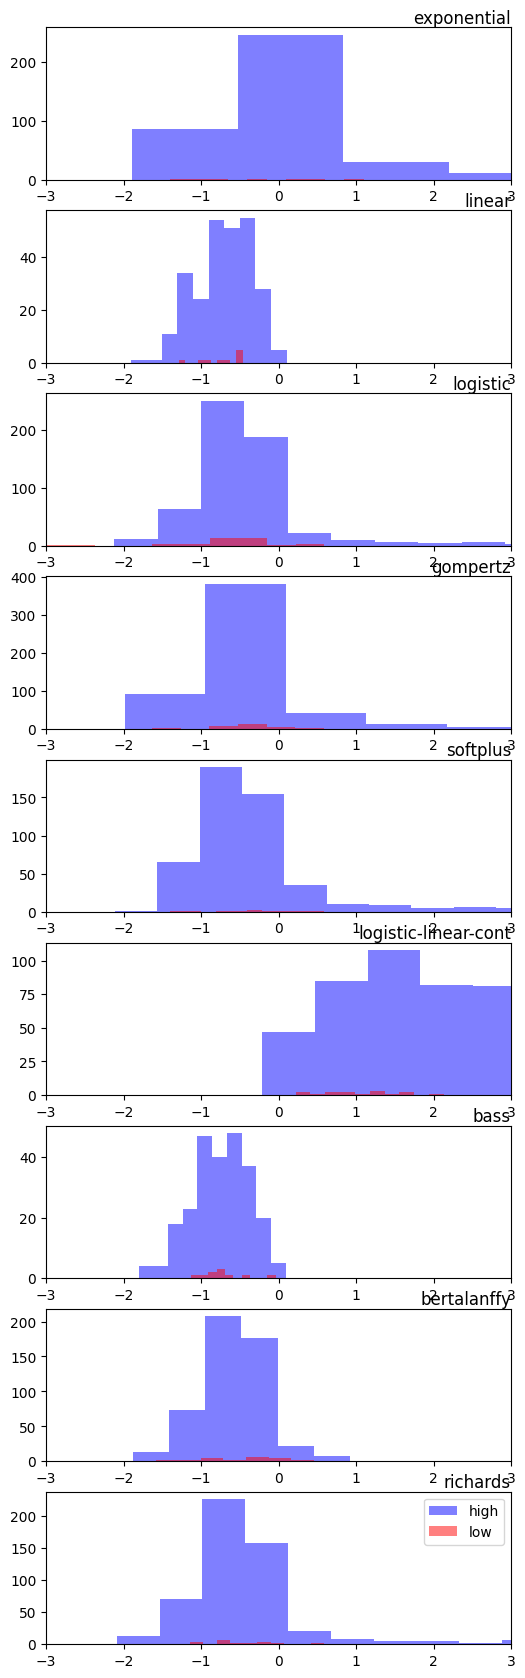

In [13]:
plot_table = full_table[(full_table["Hindcast_MAPE_log"] > -np.inf) & (full_table["Hindcast_MAPE_log"] < np.inf)]
# plot_table.groupby(['ar_high_low', 'functional_form'])['Hindcast_MAPE'].mean().unstack()

fig, ax = plt.subplots(9,1, figsize = (6,21))

count=0
for ff in plot_table['functional_form'].unique():
    ff_dy0 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['ar_high_low'] == 'high')]['Hindcast_MAPE_log']
    ff_dy1 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['ar_high_low'] == 'low')]['Hindcast_MAPE_log']
    ax[count].hist(ff_dy0, alpha = 0.5, color = 'blue', label = 'high')
    ax[count].hist(ff_dy1, alpha = 0.5, color = 'red', label = 'low')
    ax[count].set_xlim(left = -3, right = 3)
    ax[count].set_title(ff, loc='right', pad = 0)
    count += 1
    

plt.legend()
plt.show()

In [9]:
full_table['roughness_high_low'] = full_table['roughness'].apply(lambda x: 'high' if x > 0.5 else 'low')
full_table['roughness_high_low'].value_counts()

roughness_high_low
low     6885
high    3384
Name: count, dtype: int64

Text(0.5, 1.0, 'logistic')

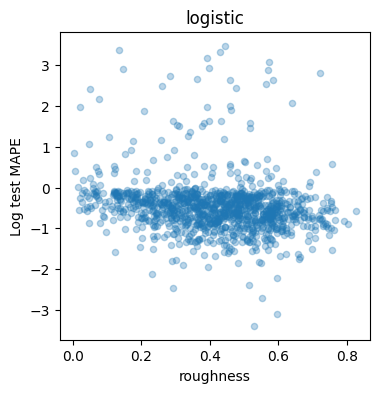

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(4,4))

full_table[full_table['functional_form'] == 'logistic'].plot.scatter(x="roughness", y="Hindcast_MAPE_log", ax=ax, alpha=0.3)

ax.set_ylabel('Log test MAPE')
ax.set_title('logistic')

Text(0.5, 1.0, 'exponential')

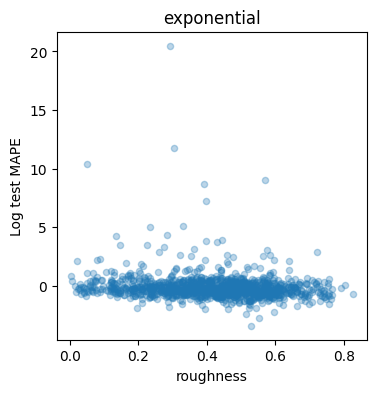

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(4,4))

full_table[full_table['functional_form'] == 'exponential'].plot.scatter(x="roughness", y="Hindcast_MAPE_log", ax=ax, alpha=0.3)

ax.set_ylabel('Log test MAPE')
ax.set_title('exponential')

Text(0.5, 1.0, 'linear')

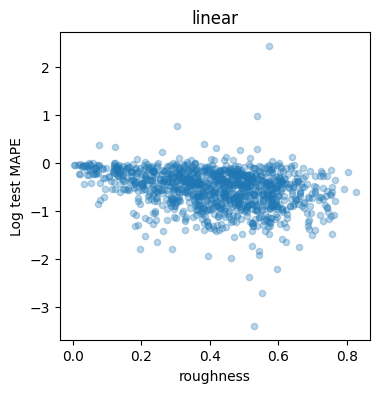

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(4,4))

full_table[full_table['functional_form'] == 'linear'].plot.scatter(x="roughness", y="Hindcast_MAPE_log", ax=ax, alpha=0.3)

ax.set_ylabel('Log test MAPE')
ax.set_title('linear')

Text(0.5, 1.0, 'bertalanffy')

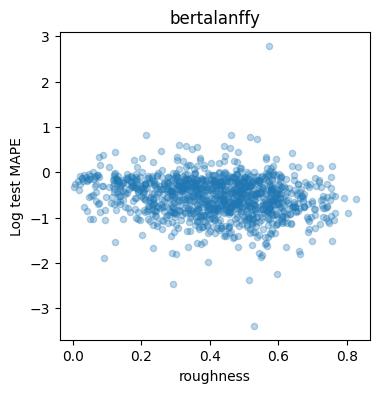

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(4,4))

full_table[full_table['functional_form'] == 'bertalanffy'].plot.scatter(x="roughness", y="Hindcast_MAPE_log", ax=ax, alpha=0.3)

ax.set_ylabel('Log test MAPE')
ax.set_title('bertalanffy')


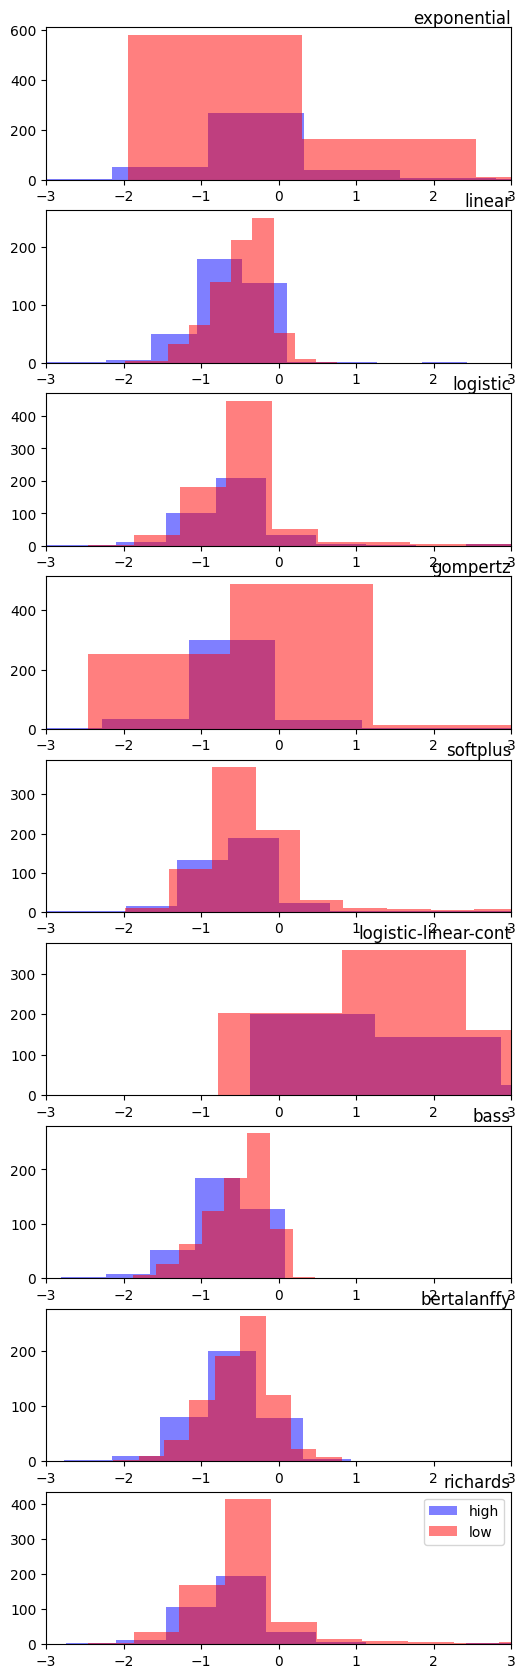

In [10]:
plot_table = full_table[(full_table["Hindcast_MAPE_log"] > -np.inf) & (full_table["Hindcast_MAPE_log"] < np.inf)]
# plot_table.groupby(['roughness_high_low', 'functional_form'])['Hindcast_MAPE'].mean().unstack()

# plot_table.groupby(['lastm_convexity_sign', 'functional_form'])['Hindcast_MAPE'].mean().unstack()
fig, ax = plt.subplots(9,1, figsize = (6,21))

count=0

for ff in plot_table['functional_form'].unique():
    ff_dy0 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['roughness_high_low'] == 'high')]['Hindcast_MAPE_log']
    ff_dy1 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['roughness_high_low'] == 'low')]['Hindcast_MAPE_log']
    ax[count].hist(ff_dy0, alpha = 0.5, color = 'blue', label = 'high')
    ax[count].hist(ff_dy1, alpha = 0.5, color = 'red', label = 'low')
    ax[count].set_xlim(left = -3, right = 3)
    ax[count].set_title(ff, loc='right', pad = 0)
    count += 1
    

plt.legend()
plt.show()

In [9]:
full_table['ts_length'] = (full_table['n'] >= 40)
full_table['ts_length'].value_counts()

ts_length
False    5382
True     4887
Name: count, dtype: int64

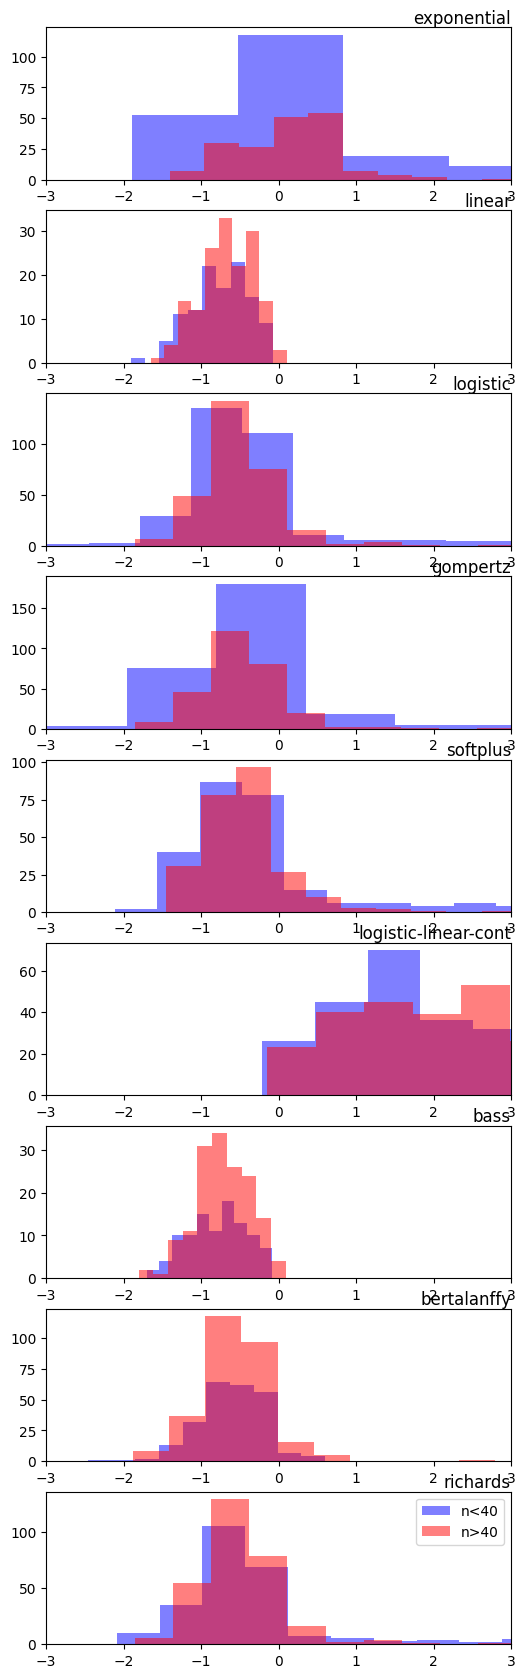

In [19]:
plot_table = full_table[(full_table["Hindcast_MAPE_log"] > -np.inf) & (full_table["Hindcast_MAPE_log"] < np.inf)]
# plot_table.groupby(['ts_length', 'functional_form'])['Hindcast_MAPE'].mean().unstack()
fig, ax = plt.subplots(9,1, figsize = (6,21))

count=0


for ff in plot_table['functional_form'].unique():
    ff_dy0 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['ts_length'] == False)]['Hindcast_MAPE_log']
    ff_dy1 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['ts_length'] == True)]['Hindcast_MAPE_log']
    ax[count].hist(ff_dy0, alpha = 0.5, color = 'blue', label = 'n<40')
    ax[count].hist(ff_dy1, alpha = 0.5, color = 'red', label = 'n>40')
    ax[count].set_xlim(left = -3, right = 3)
    ax[count].set_title(ff, loc='right', pad = 0)
    count += 1
    

plt.legend()
plt.show()

In [20]:
full_table['lastm_convexity_sign'].value_counts()

lastm_convexity_sign
1.00     2783
-1.00     943
0.00      440
Name: count, dtype: int64

In [21]:
full_table[full_table['lastm_convexity_pvalue'] < 0.33]['lastm_convexity_sign'].value_counts()

lastm_convexity_sign
1.00     2783
-1.00     943
Name: count, dtype: int64

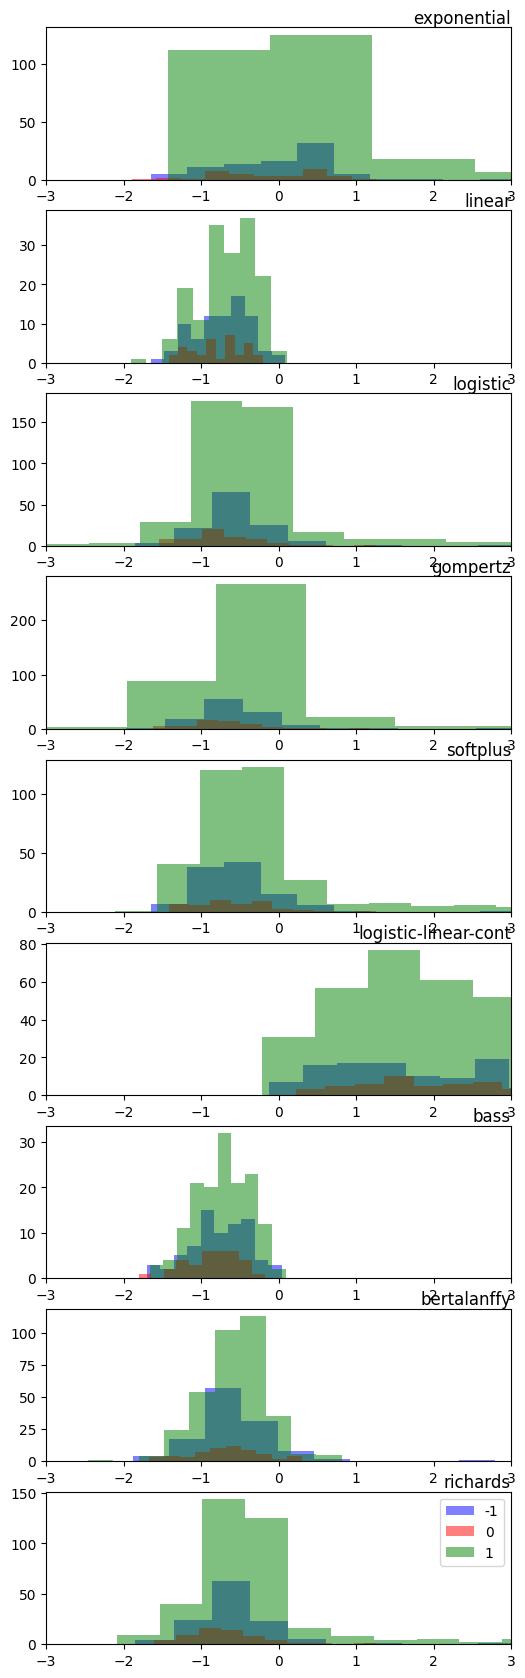

In [22]:
# plot_table.groupby(['lastm_convexity_sign', 'functional_form'])['Hindcast_MAPE'].mean().unstack()
fig, ax = plt.subplots(9,1, figsize = (6,21))

count=0
for ff in plot_table['functional_form'].unique():
    ff_dy0 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['lastm_convexity_sign'] == -1)]['Hindcast_MAPE_log']
    ff_dy1 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['lastm_convexity_sign'] == 0)]['Hindcast_MAPE_log']
    ff_dy2 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['lastm_convexity_sign'] == 1)]['Hindcast_MAPE_log']
    ax[count].hist(ff_dy0, alpha = 0.5, color = 'blue', label = '-1')
    ax[count].hist(ff_dy1, alpha = 0.5, color = 'red', label = '0')
    ax[count].hist(ff_dy2, alpha = 0.5, color = 'green', label = '1')
    ax[count].set_xlim(left = -3, right = 3)
    ax[count].set_title(ff, loc='right', pad = 0)
    count += 1
    

plt.legend()
plt.show()

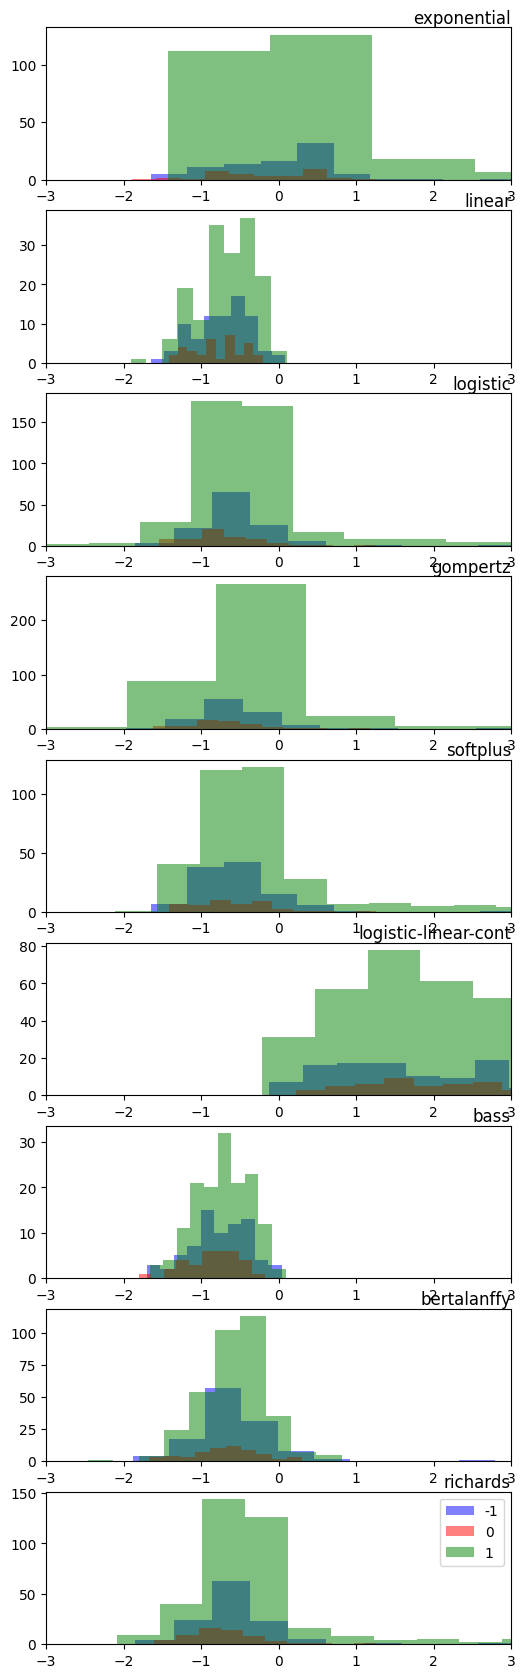

In [23]:
# plot_table.groupby(['lastm_convexity_sign', 'functional_form'])['Hindcast_MAPE'].mean().unstack()
fig, ax = plt.subplots(9,1, figsize = (6,21))

count=0
for ff in plot_table['functional_form'].unique():
    ff_dy0 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['lastm_slope_sign'] == -1)]['Hindcast_MAPE_log']
    ff_dy1 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['lastm_slope_sign'] == 0)]['Hindcast_MAPE_log']
    ff_dy2 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['lastm_slope_sign'] == 1)]['Hindcast_MAPE_log']
    ax[count].hist(ff_dy0, alpha = 0.5, color = 'blue', label = '-1')
    ax[count].hist(ff_dy1, alpha = 0.5, color = 'red', label = '0')
    ax[count].hist(ff_dy2, alpha = 0.5, color = 'green', label = '1')
    ax[count].set_xlim(left = -3, right = 3)
    ax[count].set_title(ff, loc='right', pad = 0)
    count += 1
    

plt.legend()
plt.show()

In [24]:
# position of maximum always at the end because data has been cut at maximum
full_table['y_max_rel_pos_near_end'] = (full_table['y_max_rel_pos'] > 0.95)
full_table['y_max_rel_pos_near_end'].value_counts()

C:\Users\zacht\AppData\Local\Temp\ipykernel_22216\1678716440.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_table['y_max_rel_pos_near_end'] = (full_table['y_max_rel_pos'] > 0.95)


y_max_rel_pos_near_end
False    2094
True     2072
Name: count, dtype: int64

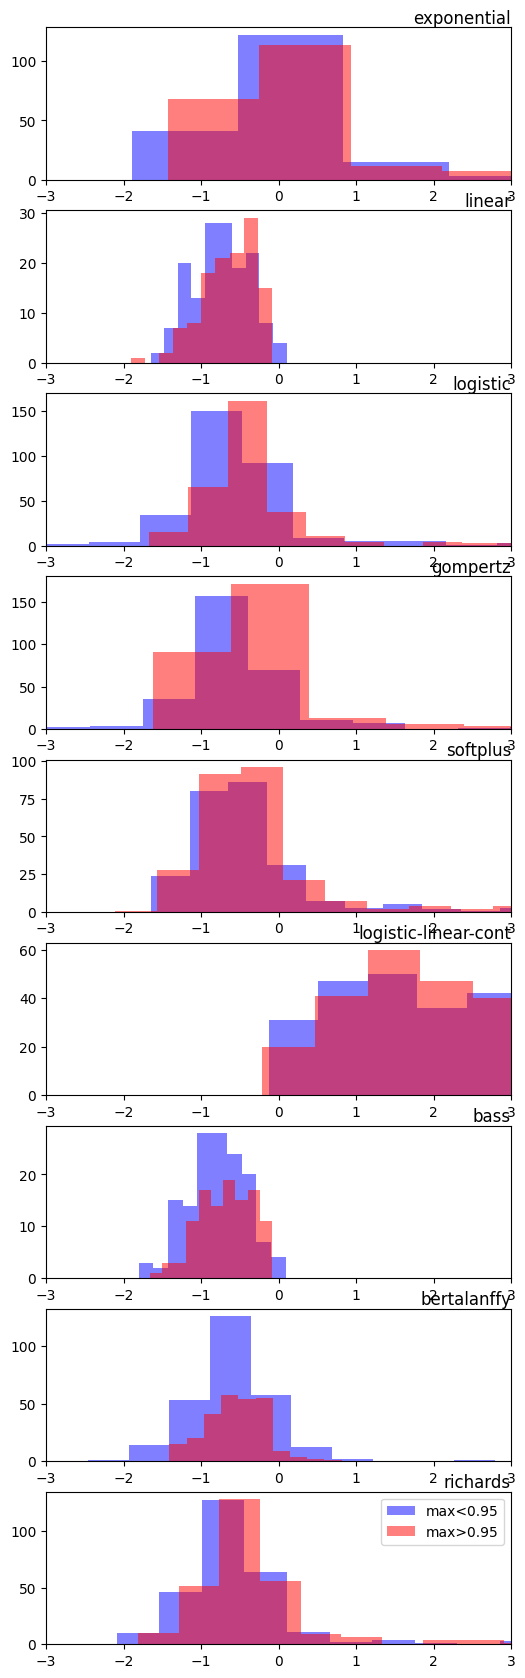

In [25]:
plot_table = full_table[(full_table["Hindcast_MAPE_log"] > -np.inf) & (full_table["Hindcast_MAPE_log"] < np.inf)]
# plot_table.groupby(['y_max_rel_pos_near_end', 'functional_form'])['Hindcast_MAPE'].mean().unstack()
fig, ax = plt.subplots(9,1, figsize = (6,21))

count=0
for ff in plot_table['functional_form'].unique():
    ff_dy0 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['y_max_rel_pos_near_end'] == False)]['Hindcast_MAPE_log']
    ff_dy1 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['y_max_rel_pos_near_end'] == True)]['Hindcast_MAPE_log']
    ax[count].hist(ff_dy0, alpha = 0.5, color = 'blue', label = 'max<0.95')
    ax[count].hist(ff_dy1, alpha = 0.5, color = 'red', label = 'max>0.95')
    ax[count].set_xlim(left = -3, right = 3)
    ax[count].set_title(ff, loc='right', pad = 0)
    count += 1
    

plt.legend()
plt.show()

In [26]:
# no drop after max because data has been cut after maximum
full_table['y_pct_mean_drop_after_max_hl'] = (full_table['y_pct_mean_drop_after_max'] > 5)
full_table['y_pct_mean_drop_after_max_hl'].value_counts()

C:\Users\zacht\AppData\Local\Temp\ipykernel_22216\2868498047.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_table['y_pct_mean_drop_after_max_hl'] = (full_table['y_pct_mean_drop_after_max'] > 5)


y_pct_mean_drop_after_max_hl
False    2543
True     1623
Name: count, dtype: int64

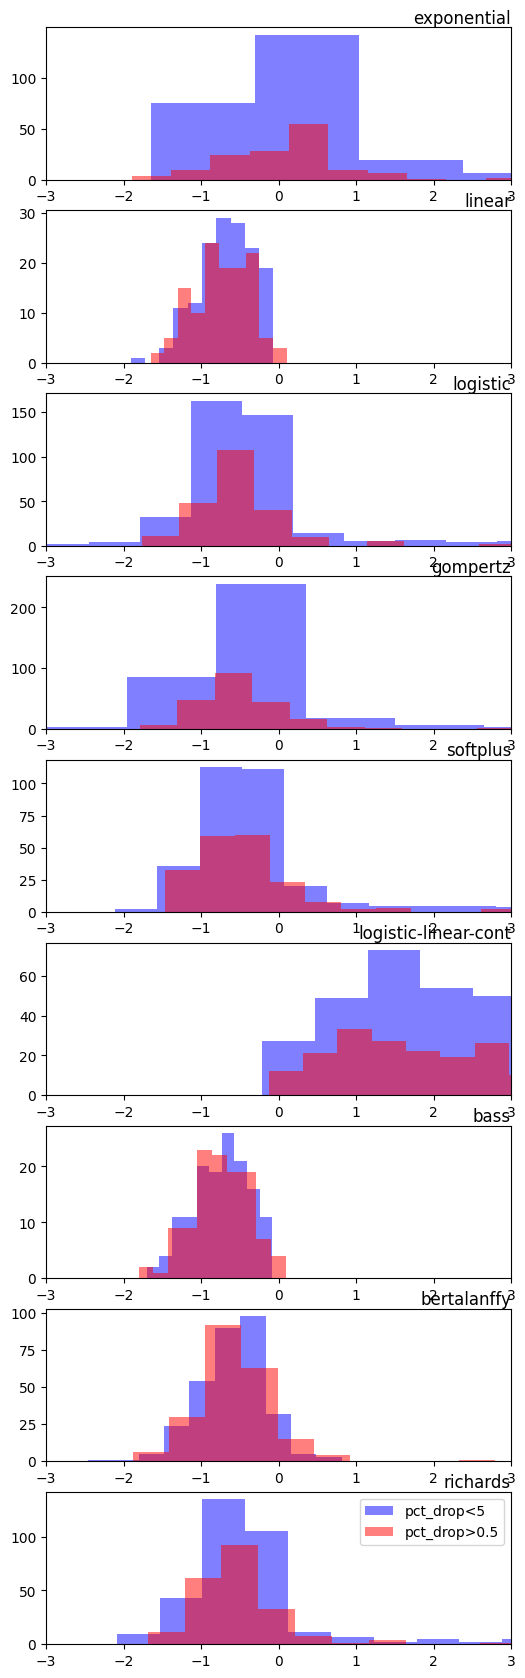

In [27]:
plot_table = full_table[(full_table["Hindcast_MAPE_log"] > -np.inf) & (full_table["Hindcast_MAPE_log"] < np.inf)]
# plot_table.groupby(['y_pct_mean_drop_after_max_hl', 'functional_form'])['Hindcast_MAPE'].mean().unstack()
fig, ax = plt.subplots(9,1, figsize = (6,21))

count=0
for ff in plot_table['functional_form'].unique():
    ff_dy0 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['y_pct_mean_drop_after_max_hl'] == False)]['Hindcast_MAPE_log']
    ff_dy1 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['y_pct_mean_drop_after_max_hl'] == True)]['Hindcast_MAPE_log']
    ax[count].hist(ff_dy0, alpha = 0.5, color = 'blue', label = 'pct_drop<5')
    ax[count].hist(ff_dy1, alpha = 0.5, color = 'red', label = 'pct_drop>0.5')
    ax[count].set_xlim(left = -3, right = 3)
    ax[count].set_title(ff, loc='right', pad = 0)
    count += 1
    

plt.legend()
plt.show()

## Using Jenna's metadata

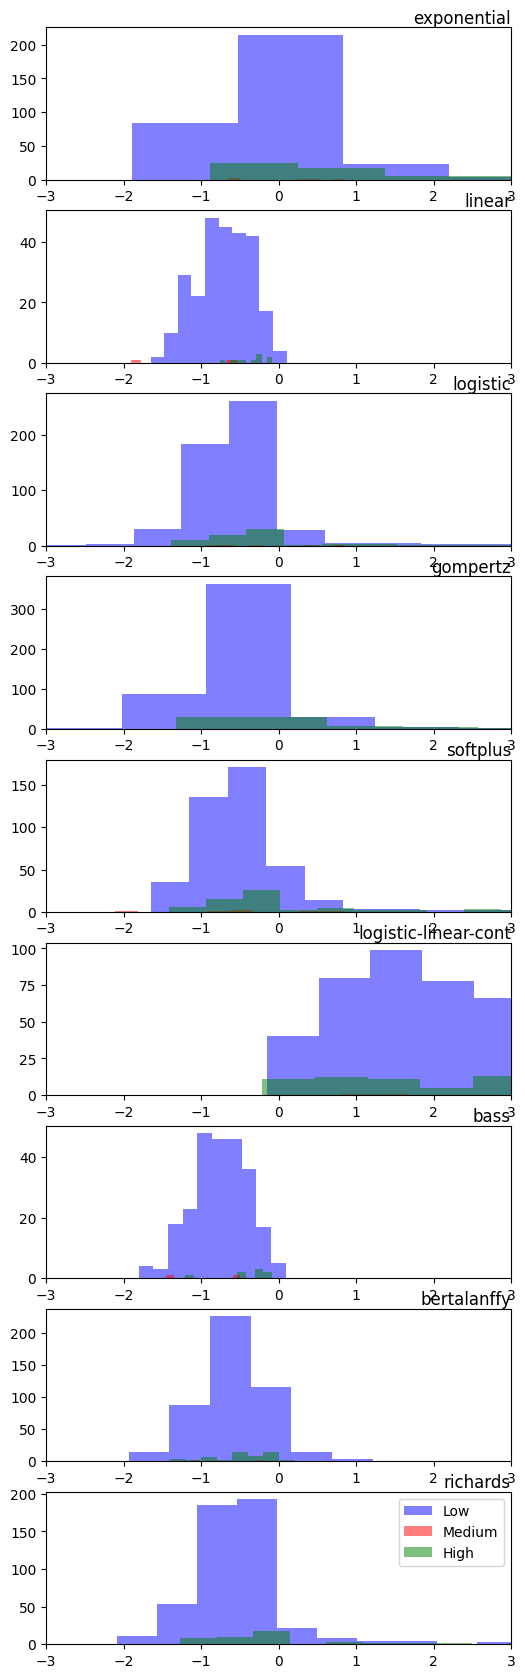

In [28]:
#plot_table.groupby(['Granularity', 'functional_form'])['Hindcast_MAPE'].mean().unstack()

fig, ax = plt.subplots(9,1, figsize = (6,21))

count=0
for ff in plot_table['functional_form'].unique():
    ff_dy0 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Granularity'] == 'Low')]['Hindcast_MAPE_log']
    ff_dy1 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Granularity'] == 'Medium')]['Hindcast_MAPE_log']
    ff_dy2 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Granularity'] == 'High')]['Hindcast_MAPE_log']
    ax[count].hist(ff_dy0, alpha = 0.5, color = 'blue', label = 'Low')
    ax[count].hist(ff_dy1, alpha = 0.5, color = 'red', label = 'Medium')
    ax[count].hist(ff_dy2, alpha = 0.5, color = 'green', label = 'High')
    ax[count].set_xlim(left = -3, right = 3)
    ax[count].set_title(ff, loc='right', pad = 0)
    count += 1
    

plt.legend()
plt.show()

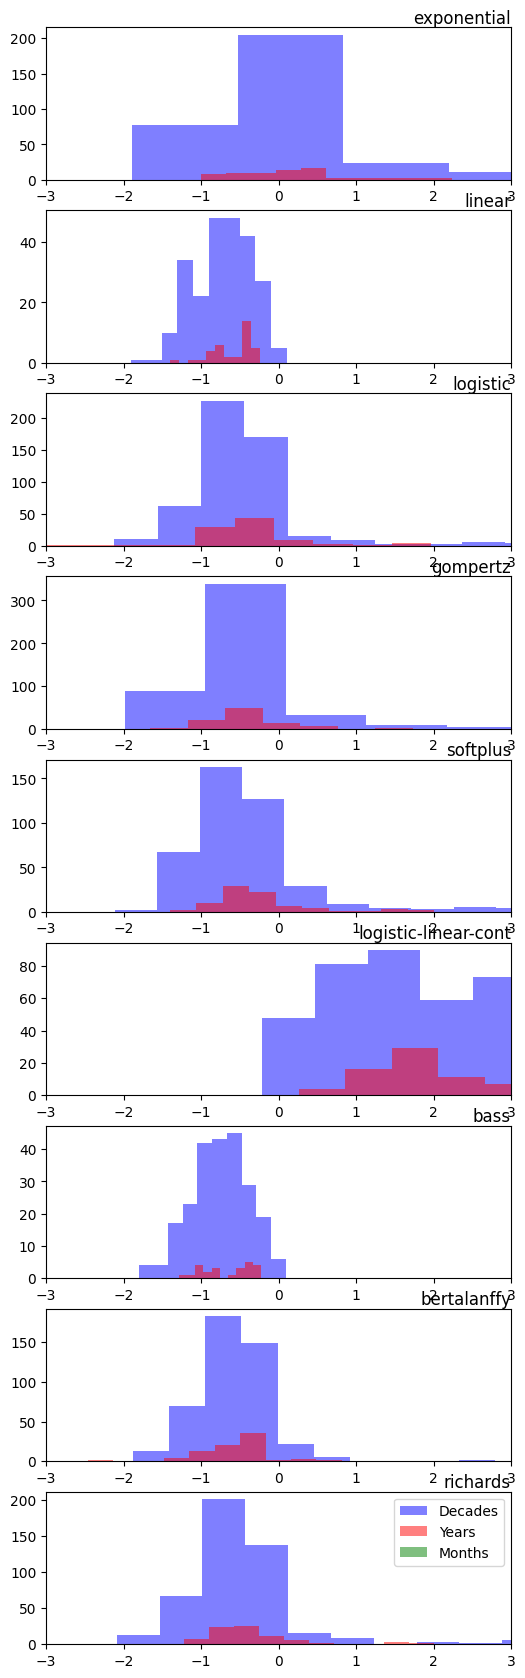

In [29]:
plot_table.groupby(['Technology Lifetime', 'functional_form'])['Hindcast_MAPE'].mean().unstack()

fig, ax = plt.subplots(9,1, figsize = (6,21))

count=0
for ff in plot_table['functional_form'].unique():
    ff_dy0 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Technology Lifetime'] == 'Decades')]['Hindcast_MAPE_log']
    ff_dy1 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Technology Lifetime'] == 'Years')]['Hindcast_MAPE_log']
    ff_dy2 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Technology Lifetime'] == 'Months')]['Hindcast_MAPE_log']
    ax[count].hist(ff_dy0, alpha = 0.5, color = 'blue', label = 'Decades')
    ax[count].hist(ff_dy1, alpha = 0.5, color = 'red', label = 'Years')
    ax[count].hist(ff_dy2, alpha = 0.5, color = 'green', label = 'Months')
    ax[count].set_xlim(left = -3, right = 3)
    ax[count].set_title(ff, loc='right', pad = 0)
    count += 1
    

plt.legend()
plt.show()

In [30]:
full_table['Complexity'].value_counts()

Complexity
Complex [3]             2650
Design-Intensive [2]     928
Simple [1]               588
Name: count, dtype: int64

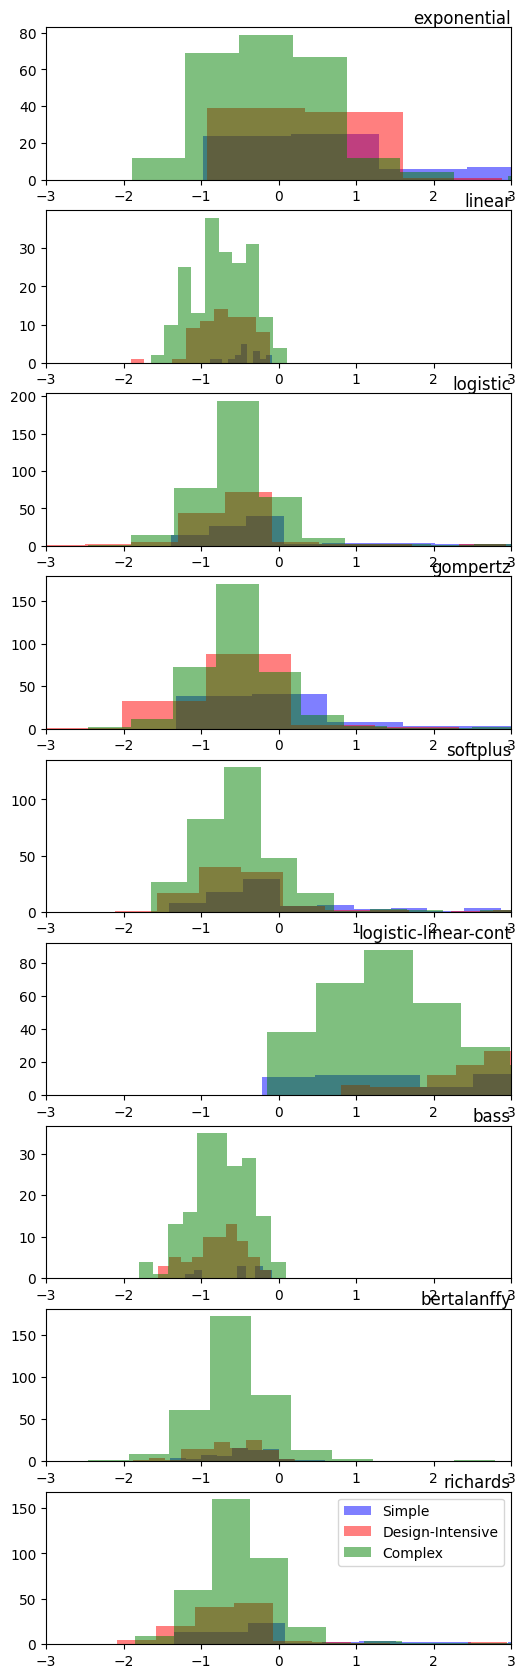

In [31]:
fig, ax = plt.subplots(9,1, figsize = (6,21))

count=0
for ff in plot_table['functional_form'].unique():
    ff_dy0 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Complexity'] == 'Simple [1]')]['Hindcast_MAPE_log']
    ff_dy1 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Complexity'] == 'Design-Intensive [2]')]['Hindcast_MAPE_log']
    ff_dy2 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Complexity'] == 'Complex [3]')]['Hindcast_MAPE_log']
    ax[count].hist(ff_dy0, alpha = 0.5, color = 'blue', label = 'Simple')
    ax[count].hist(ff_dy1, alpha = 0.5, color = 'red', label = 'Design-Intensive')
    ax[count].hist(ff_dy2, alpha = 0.5, color = 'green', label = 'Complex')
    ax[count].set_xlim(left = -3, right = 3)
    ax[count].set_title(ff, loc='right', pad = 0)
    count += 1
    

plt.legend()
plt.show()

In [32]:
full_table.loc[full_table['Need for Customization'] == 'Mass-Customized [2]', 'Need for Customization'] = 'Mass-customized [2]'
full_table['Need for Customization'].value_counts()

Need for Customization
Customized [3]         2328
Mass-customized [2]    1314
Standardized [1]        524
Name: count, dtype: int64

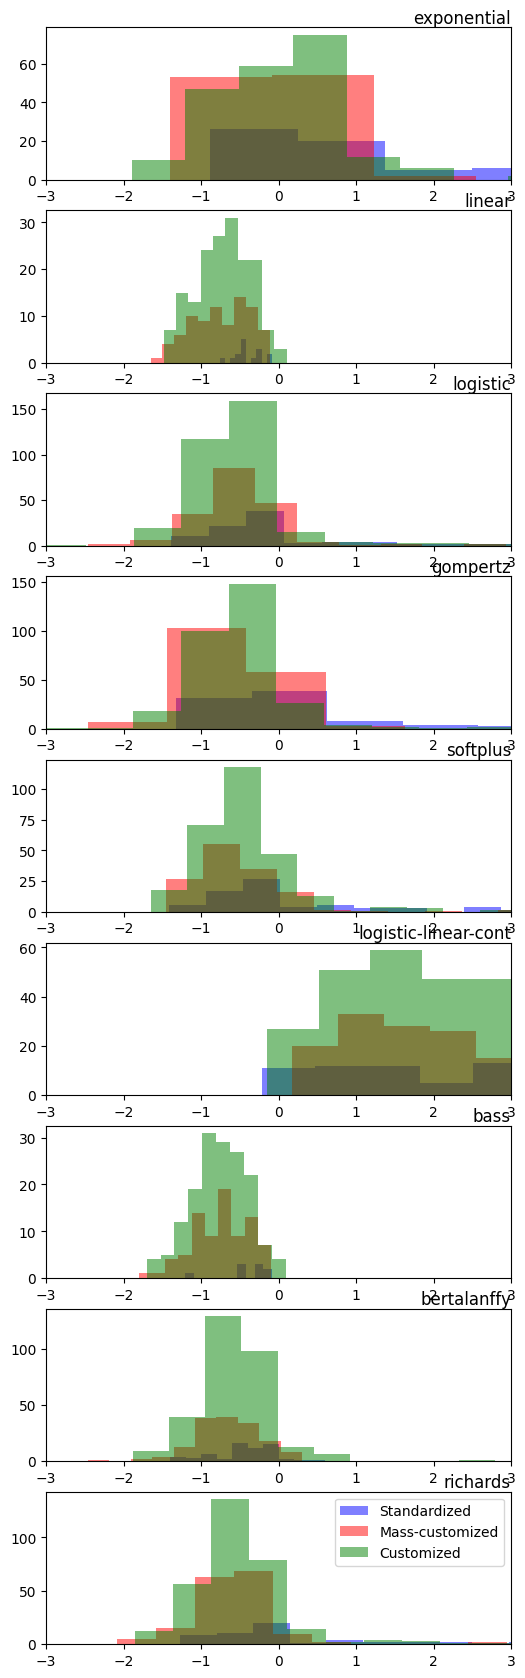

In [33]:
fig, ax = plt.subplots(9,1, figsize = (6,21))

count=0
for ff in plot_table['functional_form'].unique():
    ff_dy0 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Need for Customization'] == 'Standardized [1]')]['Hindcast_MAPE_log']
    ff_dy1 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Need for Customization'] == 'Mass-customized [2]')]['Hindcast_MAPE_log']
    ff_dy2 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Need for Customization'] == 'Customized [3]')]['Hindcast_MAPE_log']
    ax[count].hist(ff_dy0, alpha = 0.5, color = 'blue', label = 'Standardized')
    ax[count].hist(ff_dy1, alpha = 0.5, color = 'red', label = 'Mass-customized')
    ax[count].hist(ff_dy2, alpha = 0.5, color = 'green', label = 'Customized')
    ax[count].set_xlim(left = -3, right = 3)
    ax[count].set_title(ff, loc='right', pad = 0)
    count += 1
    

plt.legend()
plt.show()

In [34]:
full_table['Type of Adopter'].value_counts()

Type of Adopter
Firms [1]          2457
Both [3]           1700
Individuals [2]       9
Name: count, dtype: int64

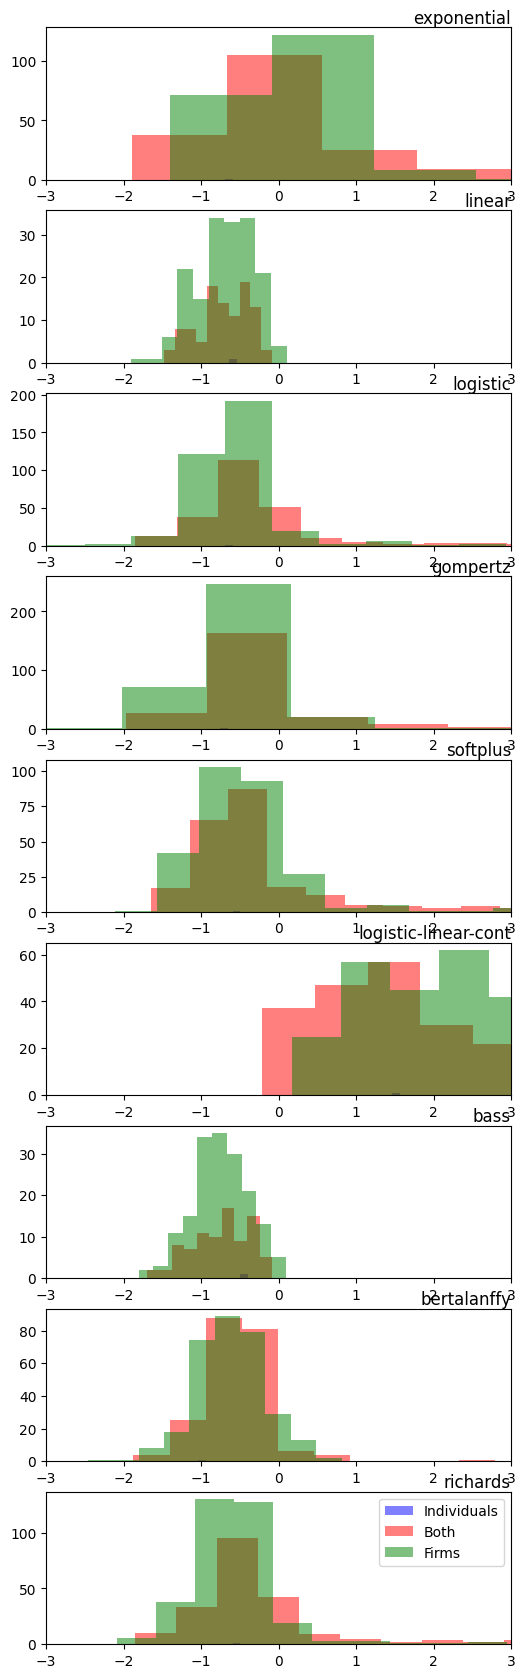

In [35]:
fig, ax = plt.subplots(9,1, figsize = (6,21))

count=0
for ff in plot_table['functional_form'].unique():
    ff_dy0 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Type of Adopter'] == 'Individuals [2]')]['Hindcast_MAPE_log']
    ff_dy1 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Type of Adopter'] == 'Both [3]')]['Hindcast_MAPE_log']
    ff_dy2 = plot_table[(plot_table['functional_form'] == ff) & (plot_table['Type of Adopter'] == 'Firms [1]')]['Hindcast_MAPE_log']
    ax[count].hist(ff_dy0, alpha = 0.5, color = 'blue', label = 'Individuals')
    ax[count].hist(ff_dy1, alpha = 0.5, color = 'red', label = 'Both')
    ax[count].hist(ff_dy2, alpha = 0.5, color = 'green', label = 'Firms')
    ax[count].set_xlim(left = -3, right = 3)
    ax[count].set_title(ff, loc='right', pad = 0)
    count += 1
    

plt.legend()
plt.show()

Text(9.319444444444445, 0.5, '')

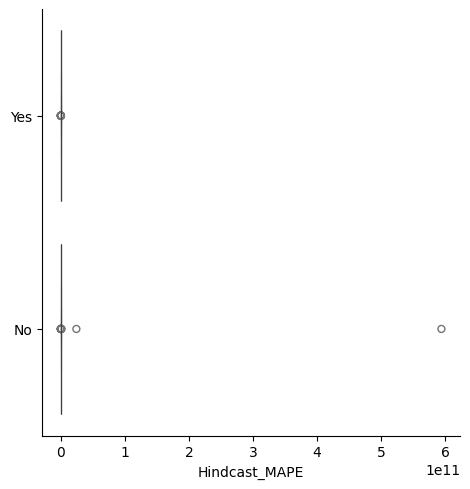

In [36]:
# distribution of Hindcast MAPE of test data

sns.catplot(y='Broad replacement', x='Hindcast_MAPE', #hue='functional_form',
            data=plot_table,
            kind='boxen', legend=False)
plt.ylabel('')

#if save_fig:
#    plt.savefig(f'figures/{sample}_{day}_adj_r_squared_dist.png', **savefig_settings)

In [24]:
full_table.columns

Index(['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'technology', 'Length_test', 'Hindcast_MAPE', 'd', 'd_std',
       'error_type', 'error_msg', 'n', 'dt_mean', 'dt_std', 'y_median',
       'y_mean', 'y_std', 'y_min', 'y_max', 'y_min_rel_pos', 'y_max_rel_pos',
       'y_pct_mean_drop_after_max', 'y_trend_slope', 'y_trend_pval', 'dy_mean',
       'dy_std', 'dy_cv', 'dy_trend_slope', 'dy_trend_pval', 'ddy_mean',
       'ddy_std', 'ddy_trend_slope', 'ddy_trend_pval', 'ar1', 'ar2',
       'roughness', 'lastm', 'lastm_convexity_sign', 'lastm_convexity_mean',
       'lastm_convexity_pvalue', 'lastm_slope_sign', 'lastm_slope_mean',
       'lastm_lin_pvalue', 'ratio_last1m_v_first', 'tech_name',
       'Technology Name', 'Material Use Numerical', 'Final Material Use',
       'Year of Invention', 'Year of First Embodiment of Tech',
       'FirstCommercialYr', 'Need for Customizatio

In [31]:
#full_table['ar2_rank'] = full_table.groupby('technology')['adj_r_squared'].rank(method='min', ascending=False)
#full_table['bestlog'] = (full_table['ar2_rank'] == 1) & (full_table['functional_form'] == 'logistic')
#full_table['bestlinear'] = (full_table['ar2_rank'] == 1) & (full_table['functional_form'] == 'linear')
#full_table['bestexp'] = (full_table['ar2_rank'] == 1) & (full_table['functional_form'] == 'exponential')

best_subset = full_table#.loc[full_table['ar2_rank'] == 1]

In [32]:
best_corr = best_subset.corr(numeric_only=True)
best_corr.columns

Index(['fit_success', 'r_squared', 'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a',
       'b', 'c', 'a_std', 'b_std', 'c_std', 'Length_test', 'Hindcast_MAPE',
       'd', 'd_std', 'n', 'dt_mean', 'dt_std', 'y_median', 'y_mean', 'y_std',
       'y_min', 'y_max', 'y_min_rel_pos', 'y_max_rel_pos',
       'y_pct_mean_drop_after_max', 'y_trend_slope', 'y_trend_pval', 'dy_mean',
       'dy_std', 'dy_cv', 'dy_trend_slope', 'dy_trend_pval', 'ddy_mean',
       'ddy_std', 'ddy_trend_slope', 'ddy_trend_pval', 'ar1', 'ar2',
       'roughness', 'lastm', 'lastm_convexity_sign', 'lastm_convexity_mean',
       'lastm_convexity_pvalue', 'lastm_slope_sign', 'lastm_slope_mean',
       'lastm_lin_pvalue', 'ratio_last1m_v_first', 'Material Use Numerical',
       'Average lifetime', 'Hindcast_MAPE_log'],
      dtype='object')